In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This tells matplotlib to show graphs inside the notebook
%matplotlib inline

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [80]:
# Load the dataset
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')



FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [82]:
import os
print(os.getcwd())


C:\Users\Janhavi


In [84]:
# Load the dataset using the FULL path (works 100% of the time)
df = pd.read_csv(r'C:\Users\Janhavi\ChurnProject\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [86]:
df.shape

(7043, 21)

In [88]:
print("Shape:", df.shape)
print(f"We have {df.shape[0]} customers and {df.shape[1]} columns")


Shape: (7043, 21)
We have 7043 customers and 21 columns


In [90]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [92]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [94]:
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [96]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)  # as percentages


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


C:\Users\Janhavi\AppData\Local\Temp\ipykernel_27284\2755640451.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


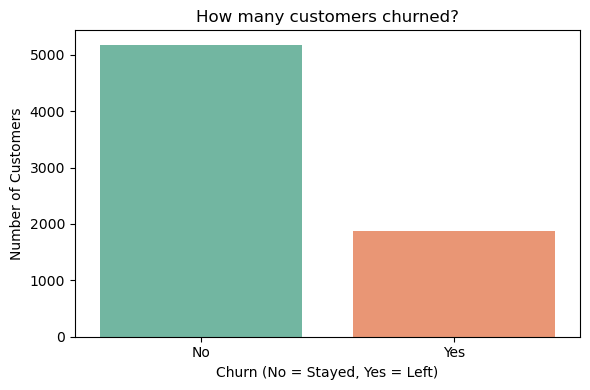

In [98]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('How many customers churned?')
plt.xlabel('Churn (No = Stayed, Yes = Left)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


C:\Users\Janhavi\AppData\Local\Temp\ipykernel_27284\1649443382.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')


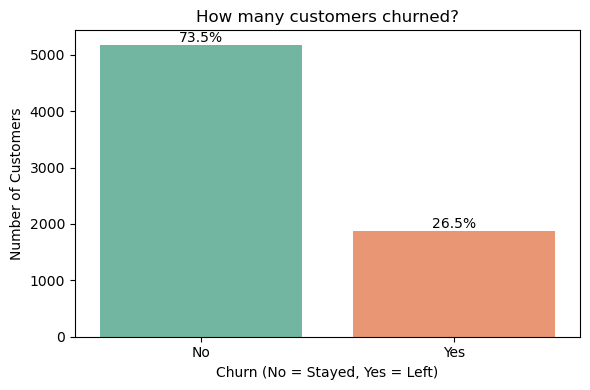

In [100]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')

# Total count for percentage calculation
total = len(df)

# Add percentage labels
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom')

plt.title('How many customers churned?')
plt.xlabel('Churn (No = Stayed, Yes = Left)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [101]:
# Convert TotalCharges from text to number
# errors='coerce' means: if it can't convert, put NaN instead
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values appeared
print("NaN values in TotalCharges:", df['TotalCharges'].isnull().sum())


NaN values in TotalCharges: 11


In [104]:
df.dropna(subset=['TotalCharges'], inplace=True)

print("Rows after cleaning:", len(df))
# Should be 7032 (7043 - 11)


Rows after cleaning: 7032


In [106]:
# customerID is just a label, like a name tag
# It has no predictive power — every value is unique
df.drop('customerID', axis=1, inplace=True)

print("Columns now:", df.columns.tolist())


Columns now: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [108]:
# ML models need numbers, not words
# Yes = 1 (churned), No = 0 (stayed)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df['Churn'].value_counts())


Churn
0    5163
1    1869
Name: count, dtype: int64


In [110]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nAny nulls?")
print(df.isnull().sum().sum(), "total missing values")


Shape: (7032, 20)

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Any nulls?
0 total missing values


In [112]:
df.to_csv(r'C:\Users\Janhavi\ChurnProject\data\processed\telco_clean.csv', index=False)
print("✅ Clean data saved!")


✅ Clean data saved!


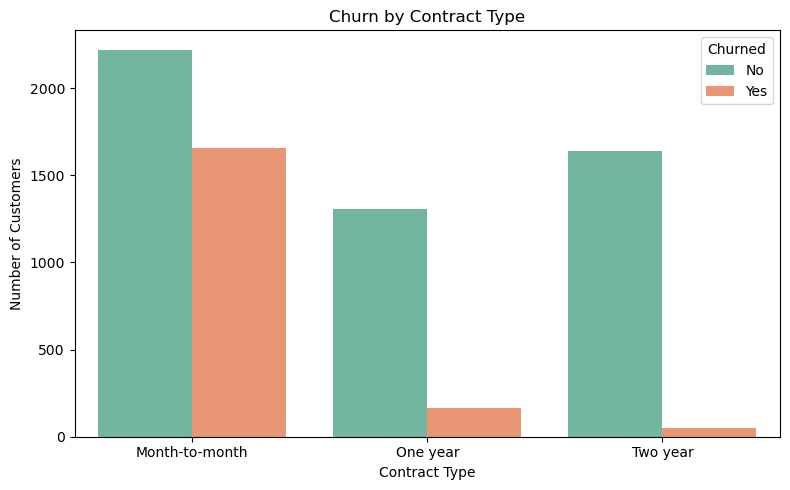

In [114]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churned', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


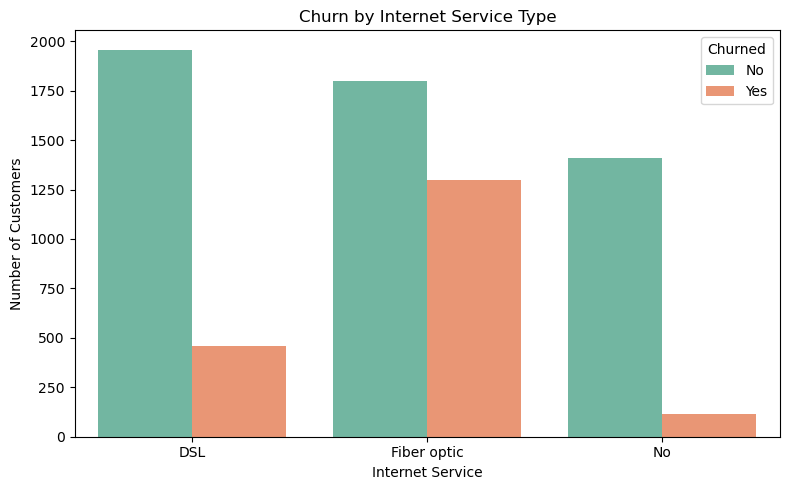

In [115]:
plt.figure(figsize=(8, 5))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churned', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


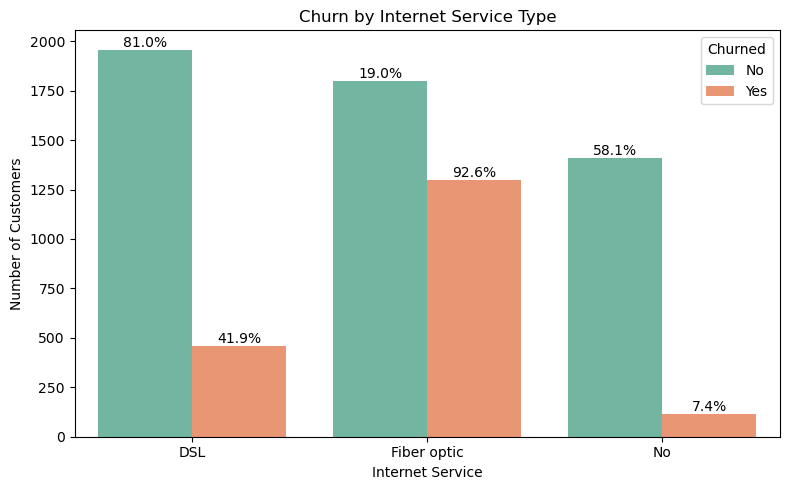

In [117]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')

# Get counts
counts = df.groupby(['InternetService', 'Churn']).size().unstack().fillna(0)

# Convert to %
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

# Annotate bars
for i, p in enumerate(ax.patches):
    height = p.get_height()
    if height == 0:
        continue
    
    # Get position
    x = p.get_x() + p.get_width() / 2.
    
    # Determine indices
    contract_index = i // 2   # category index
    churn_index = i % 2       # 0 = No, 1 = Yes
    
    percent = percentages.iloc[contract_index, churn_index]
    
    ax.text(x, height, f'{percent:.1f}%', ha='center', va='bottom')

plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churned', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

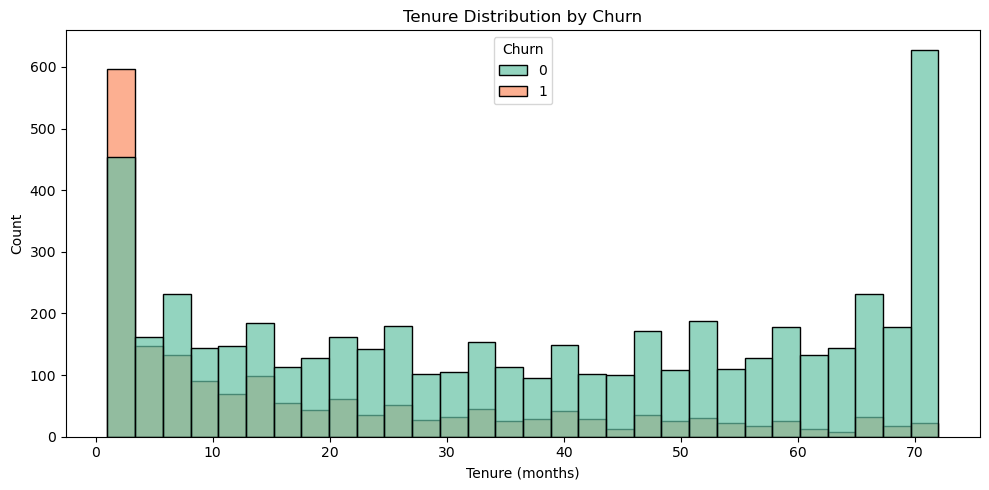

In [119]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2', alpha=0.7)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


<Axes: xlabel='Churn', ylabel='tenure'>

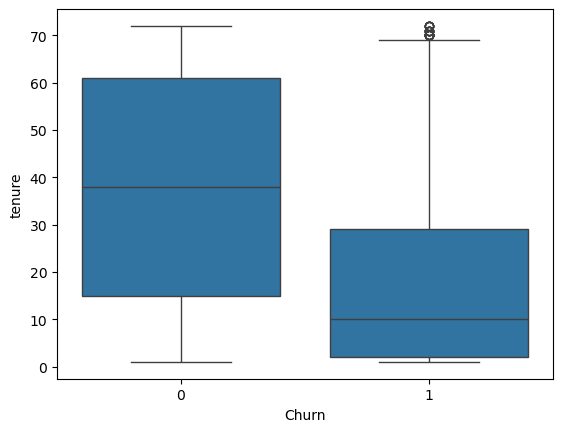

In [121]:
sns.boxplot(x='Churn', y='tenure', data=df)

<Axes: xlabel='tenure', ylabel='Count'>

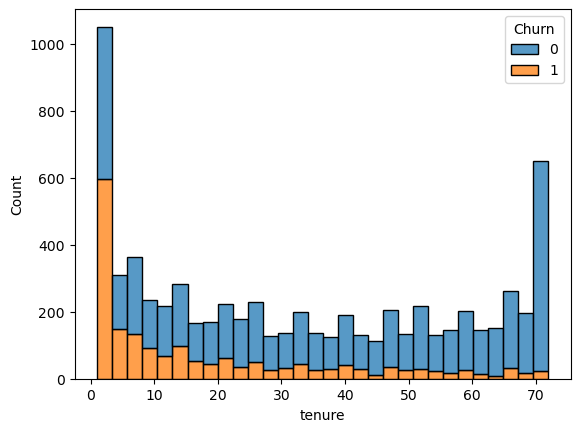

In [122]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='stack')

C:\Users\Janhavi\AppData\Local\Temp\ipykernel_27284\605043014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')


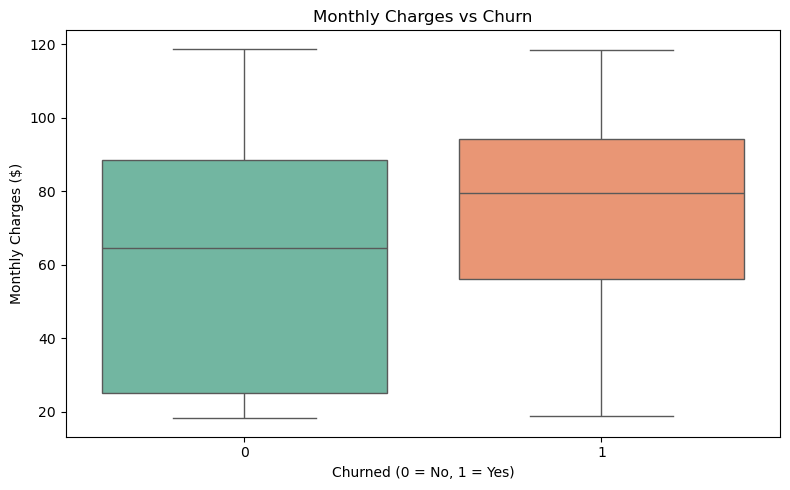

In [124]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churned (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()


## 📊 Key Insights from Visual Analysis

1. **Contract type is the #1 churn driver** — Month-to-month customers churn at ~42% vs 11% for annual contracts
2. **New customers are most at risk** — Majority of churn happens in the first 12 months
3. **High monthly charges = higher churn** — Customers paying more feel less value
4. **Fiber optic users churn more** — Possible pricing or quality dissatisfaction

### Business Recommendation:
- Offer discounts to convert month-to-month customers to annual contracts
- Create a "first 12 months retention program" for new customers
